# Train model

In [12]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'mix_train'
label_column = 'target'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [13]:
filename = os.path.join(context['portfolio_dir'], "features.parquet")
df = pd.read_parquet(filename)
# unisci le righe di tutti i dataframe in uno solo
df = df.dropna()
df.shape

(528180, 18)

## EDA

In [14]:
df.describe()

,day_of_week,time_since_high,close,log_return,mom_5,mom_10,mom_rank,vol_10,vol_20,vol_ratio,zscore_20,trend_50,volume_zscore,volume_shock,vol_regime,target
count,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000,528180.000000
mean,2.026048,469.213181,91.820592,0.000985,0.004515,0.009005,0.000317,0.039754,0.046402,0.873287,0.077554,0.008137,0.025020,1.019656,0.946299,0.015466
std,1.398562,450.047454,127.340282,0.070072,0.282698,0.404569,0.996488,0.040535,0.043078,0.270948,1.305098,0.149895,1.041491,0.632580,0.348872,1.776030
min,0.000000,0.000000,0.049900,-2.506714,-0.918464,-0.916102,-8.912825,0.000000,0.000720,0.000000,-4.238322,-0.914594,-3.579180,0.000000,0.000000,-96.566741
25%,1.000000,89.000000,24.960000,-0.025762,-0.025433,-0.036138,-0.385011,0.020095,0.025685,0.675923,-0.979924,-0.047057,-0.645266,0.696993,0.703071,-0.690064
50%,2.000000,323.000000,52.420000,0.001756,0.001757,0.003263,-0.052282,0.030806,0.037271,0.888814,0.125139,0.005030,-0.238755,0.895680,0.902190,0.050404
75%,3.000000,752.000000,107.920000,0.028720,0.029136,0.043637,0.317616,0.047984,0.055270,1.085132,1.140572,0.058140,0.428427,1.168740,1.140023,0.765488
max,4.000000,1813.000000,2715.060000,4.454347,85.000000,85.000000,21.487232,2.323013,1.971569,1.452558,4.248529,30.337599,4.248529,20.000000,2.558859,326.018024


In [15]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 528180 entries, 60 to 558703
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   day_of_week      528180 non-null  int32  
 1   time_since_high  528180 non-null  int64  
 2   close            528180 non-null  float64
 3   log_return       528180 non-null  float64
 4   mom_5            528180 non-null  float64
 5   mom_10           528180 non-null  float64
 6   mom_rank         528180 non-null  float64
 7   vol_10           528180 non-null  float64
 8   vol_20           528180 non-null  float64
 9   vol_ratio        528180 non-null  float64
 10  zscore_20        528180 non-null  float64
 11  trend_50         528180 non-null  float64
 12  volume_zscore    528180 non-null  float64
 13  volume_shock     528180 non-null  float64
 14  vol_regime       528180 non-null  float64
 15  target           528180 non-null  float64
dtypes: float64(14), int32(1), int64(1)
memory usage: 66.5

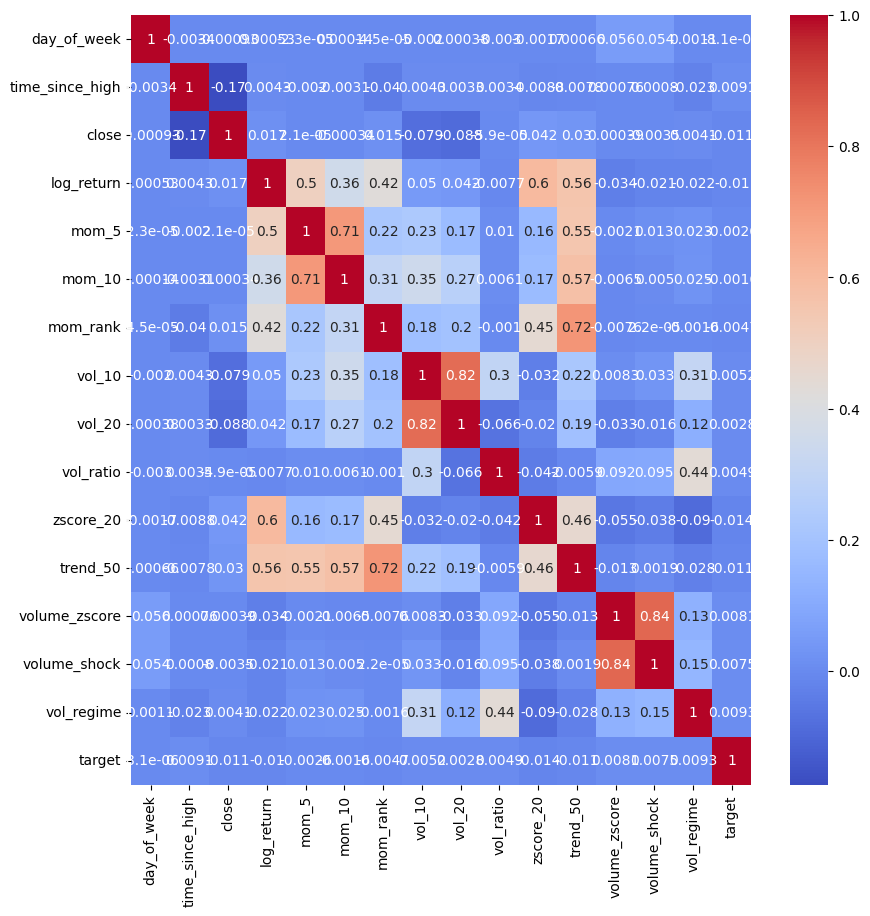

In [16]:
# display the correlation map using seaborn
plt.figure(figsize=(10, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

## Normalize

In [17]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins[label_column]
label_max = maxs[label_column]
hayai_util.save_normalization_params(label_min, label_max)

True

## Model building

In [18]:
labels = df[label_column].values
df = df.drop(columns=[label_column])
data = df.values


In [19]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (528180,)
Data Shape: (528180, 15)
Train Data Shape: (422544, 15)
Train Labels Shape: (422544,)
Test Data Shape: (105636, 15)
Test Labels Shape: (105636,)


In [20]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(32, activation='relu',name='layerDense1'))
model.add(Dense(16, activation='relu',name='layerDense2'))
model.add(Dense(8, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/20
5282/5282 - 6s - 1ms/step - loss: 6.9530e-04 - val_loss: 1.6394e-05
Epoch 2/20
5282/5282 - 6s - 1ms/step - loss: 1.9952e-05 - val_loss: 2.1953e-05
Epoch 3/20
5282/5282 - 6s - 1ms/step - loss: 1.9479e-05 - val_loss: 1.5563e-05
Epoch 4/20
5282/5282 - 6s - 1ms/step - loss: 1.9284e-05 - val_loss: 1.5867e-05
Epoch 5/20
5282/5282 - 8s - 1ms/step - loss: 1.9133e-05 - val_loss: 1.5703e-05
Epoch 6/20
5282/5282 - 14s - 3ms/step - loss: 1.9036e-05 - val_loss: 1.7960e-05
Epoch 7/20
5282/5282 - 20s - 4ms/step - loss: 1.8965e-05 - val_loss: 1.5241e-05
Epoch 8/20
5282/5282 - 21s - 4ms/step - loss: 1.8917e-05 - val_loss: 1.5416e-05
Epoch 9/20
5282/5282 - 14s - 3ms/step - loss: 1.8816e-05 - val_loss: 1.5125e-05
Epoch 10/20
5282/5282 - 20s - 4ms/step - loss: 1.8786e-05 - val_loss: 1.5187e-05
Epoch 11/20
5282/5282 - 14s - 3ms/step - loss: 1.8774e-05 - val_loss: 1.5282e-05
Epoch 12/20
5282/5282 - 14s - 3ms/step - loss: 1.8721e-05 - val_loss: 1.5553e-05
Epoch 13/20
5282/5282 - 20s - 4ms/step - l

Model saved to: data\mix_train\model.keras


In [22]:
tp = 0
tn = 0
fp = 0
fn = 0
print(label_min, label_max, label_max - label_min)
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

-96.56674064883275 326.0180244725513 422.58476512138407
Label: 3.5480, Prediction: 0.0503
Label: -0.7173, Prediction: 0.0982
Label: -0.9894, Prediction: 0.0533
Label: -0.9804, Prediction: 0.1018
Label: 0.3429, Prediction: 0.0841
Label: -0.3033, Prediction: 0.0779
Label: 1.3737, Prediction: 0.0772
Label: 0.6754, Prediction: 0.1060
Label: 0.0133, Prediction: 0.1060
Label: -0.0862, Prediction: 0.0614
Label: 0.5942, Prediction: 0.1048
Label: -1.6501, Prediction: 0.0659
Label: 2.2245, Prediction: 0.0506
Label: -1.5222, Prediction: 0.1248
Label: -1.4076, Prediction: 0.0581
Label: -1.0343, Prediction: 0.0779
Label: -1.0661, Prediction: 0.1060
Label: -0.7706, Prediction: 0.0871
Label: 2.9713, Prediction: 0.0726
Label: -0.1359, Prediction: 0.0722
Label: 0.2410, Prediction: 0.0502
Label: 0.3272, Prediction: 0.0663
Label: -0.7992, Prediction: 0.0640
Label: -1.0403, Prediction: 0.0670
Label: -0.7915, Prediction: 0.1060
Label: 1.1037, Prediction: 0.0603
Label: 2.2250, Prediction: 0.0731
Label: -0.8